## 1. Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

## 2. Load the Dataset





In [ ]:
df = pd.read_csv("healthcare-dataset-stroke-data.xls")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 3. Basic Data Inspection



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
print("\nMissing values:")
print(df.isnull().sum())

print("\nStroke class distribution:")
print(df["stroke"].value_counts())


Missing values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Stroke class distribution:
stroke
0    4861
1     249
Name: count, dtype: int64


## 4. Exploratory Data Analysis

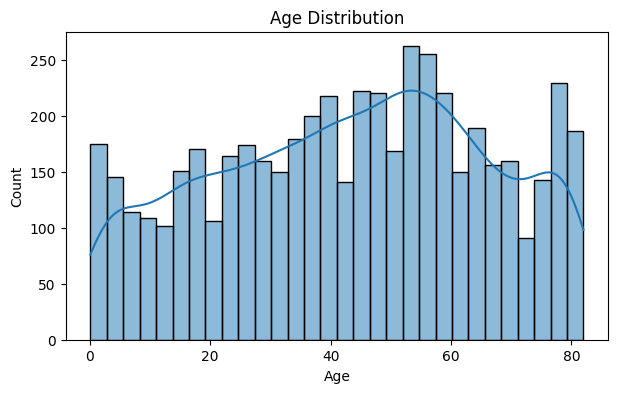

In [ ]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="age", bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

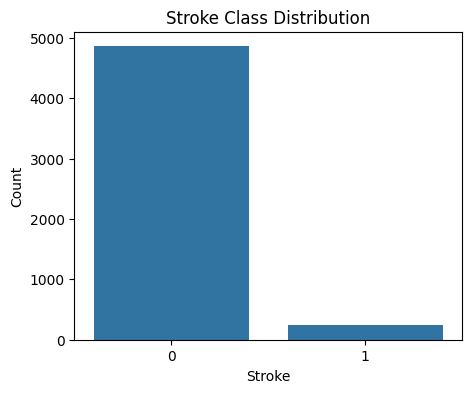

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="stroke")
plt.title("Stroke Class Distribution")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

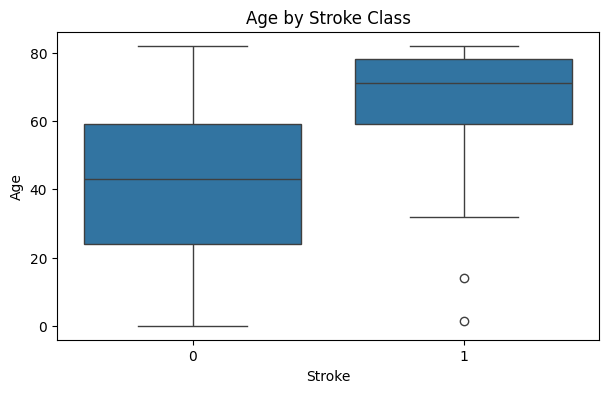

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="stroke", y="age")
plt.title("Age by Stroke Class")
plt.xlabel("Stroke")
plt.ylabel("Age")
plt.show()

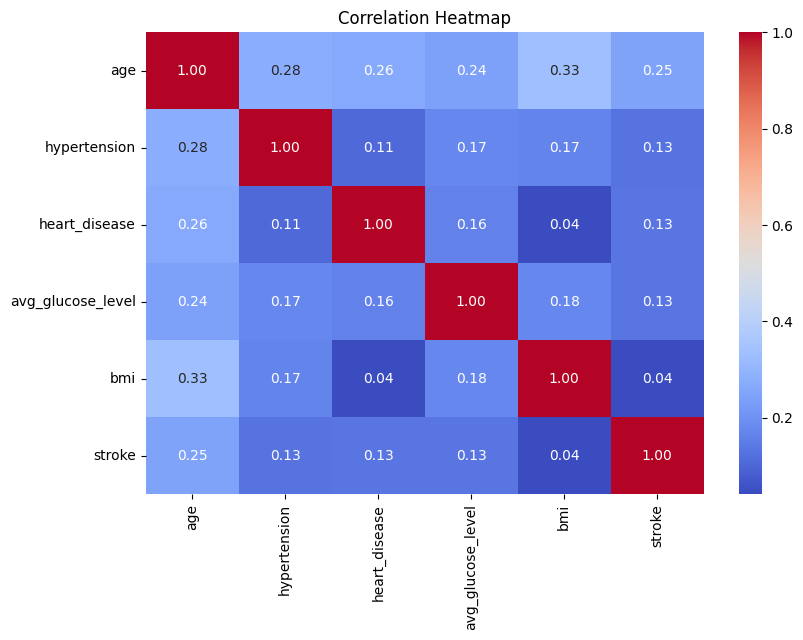

In [ ]:
numeric_for_corr = df.select_dtypes(include=np.number).drop(columns=["id"], errors="ignore")

plt.figure(figsize=(9, 6))
sns.heatmap(numeric_for_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 5. Prepare Features and Target

The `id` column is removed because it is only an identifier and should not be used to predict stroke.

I split the data **before** fitting preprocessing steps or applying SMOTE. This helps prevent data leakage.

In [ ]:
target = "stroke"

X = df.drop(columns=[target, "id"], errors="ignore")
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

Training shape: (4088, 10)
Testing shape: (1022, 10)

Training target distribution:
stroke
0    3889
1     199
Name: count, dtype: int64


## 6. Preprocessing

For numerical columns:
- missing values are filled with the median
- values are standardized

For categorical columns:
- missing values are filled with the most frequent value
- categories are converted using one-hot encoding

In [ ]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

numeric_pipeline = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols)
    ]
)

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Categorical columns: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


## 7. Models

I compare five classification algorithms. Since stroke cases are much less common than non-stroke cases, SMOTE is applied **only to the training data inside each pipeline**.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    ),
    "SVM": SVC(random_state=RANDOM_STATE),
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=1000,
        random_state=RANDOM_STATE
    )
}

## 8. Train and Evaluate the Models

Because the dataset is imbalanced, I pay special attention to **recall** and **F1-score**, not only accuracy.

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.55      1022
weighted avg       0.95      0.75      0.82      1022



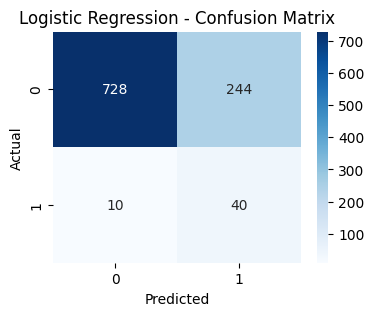

Decision Tree
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       972
           1       0.10      0.16      0.12        50

    accuracy                           0.89      1022
   macro avg       0.53      0.54      0.53      1022
weighted avg       0.91      0.89      0.90      1022



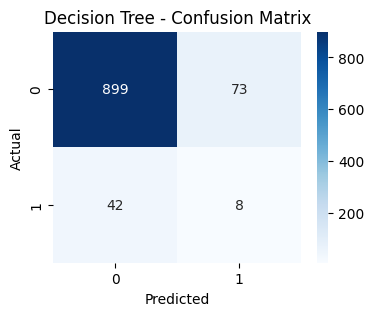

Random Forest
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       972
           1       0.12      0.10      0.11        50

    accuracy                           0.92      1022
   macro avg       0.54      0.53      0.53      1022
weighted avg       0.91      0.92      0.92      1022



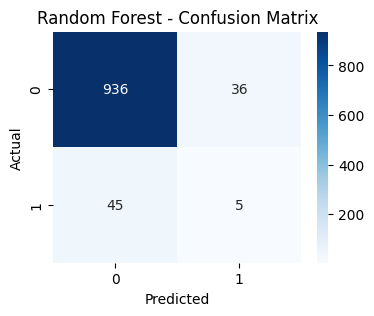

SVM
              precision    recall  f1-score   support

           0       0.97      0.80      0.88       972
           1       0.11      0.48      0.18        50

    accuracy                           0.79      1022
   macro avg       0.54      0.64      0.53      1022
weighted avg       0.93      0.79      0.84      1022



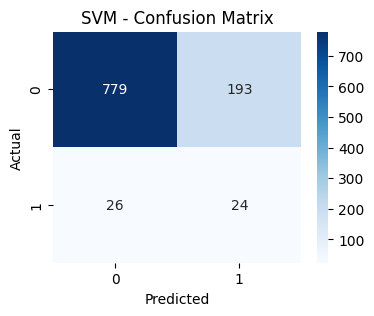

Neural Network
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       972
           1       0.10      0.14      0.12        50

    accuracy                           0.90      1022
   macro avg       0.53      0.54      0.53      1022
weighted avg       0.91      0.90      0.90      1022



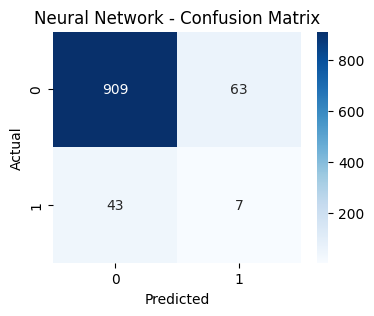

In [ ]:
results = {}
trained_pipelines = {}

for name, model in models.items():
    pipeline = ImbPipeline(steps=[
        ("preprocessing", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions, zero_division=0)
    rec = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    }

    trained_pipelines[name] = pipeline

    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(y_test, predictions, zero_division=0))

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("F1 Score", ascending=False)

results_df.round(4)

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.7515,0.1408,0.80,0.2395
SVM,0.7857,0.1106,0.48,0.1798
Decision Tree,0.8875,0.0988,0.16,0.1221
Neural Network,0.8963,0.1000,0.14,0.1167
Random Forest,0.9207,0.1220,0.10,0.1099


## 9. Compare Model Performance

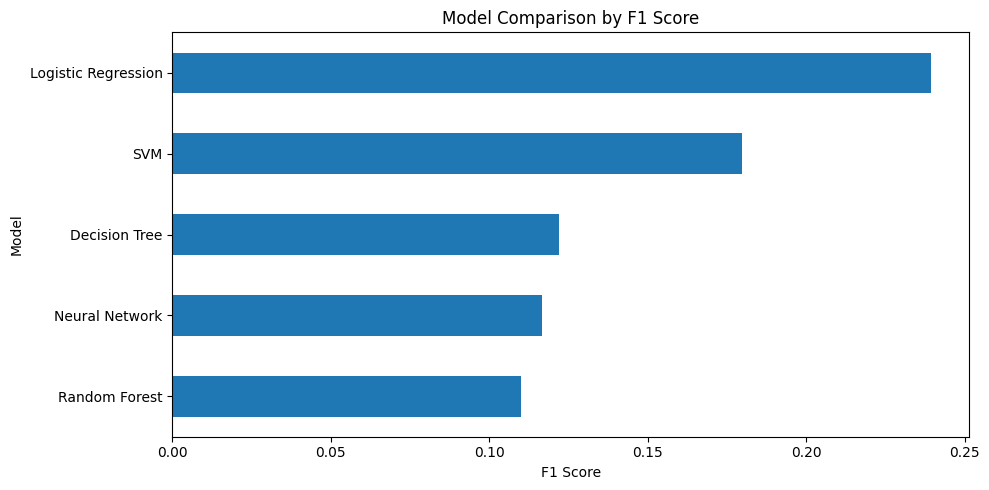

In [ ]:
plt.figure(figsize=(10, 5))
results_df["F1 Score"].sort_values().plot(kind="barh")
plt.title("Model Comparison by F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [ ]:
best_model_name = results_df["F1 Score"].idxmax()
best_f1 = results_df.loc[best_model_name, "F1 Score"]

print(f"Best model based on test F1 Score: {best_model_name}")
print(f"F1 Score: {best_f1:.4f}")

Best model based on test F1 Score: Logistic Regression
F1 Score: 0.2395


## 10. 5-Fold Cross-Validation

Cross-validation gives a more stable estimate of performance.

The full preprocessing + SMOTE + model pipeline is evaluated inside every fold so that information from validation folds does not leak into training.

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = {}

for name, model in models.items():
    pipeline = ImbPipeline(steps=[
        ("preprocessing", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="f1"
    )

    cv_results[name] = {
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    }

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df.sort_values("Mean CV F1", ascending=False).round(4)

,Mean CV F1,Std CV F1
Logistic Regression,0.2291,0.0182
SVM,0.1828,0.0144
Decision Tree,0.1290,0.0507
Random Forest,0.1185,0.0364
Neural Network,0.1046,0.0349


## 11. K-Means Clustering

As a small unsupervised learning experiment, I also use K-Means clustering with two clusters.

The clustering section is separate from the stroke prediction models and is mainly included to explore whether the dataset naturally forms groups after preprocessing.

In [ ]:
X_cluster = preprocessor.fit_transform(X)

kmeans = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=10
)

clusters = kmeans.fit_predict(X_cluster)

cluster_df = df.copy()
cluster_df["cluster"] = clusters

silhouette = silhouette_score(X_cluster, clusters)

print("Silhouette Score:", round(silhouette, 4))
print("\nCluster distribution:")
print(cluster_df["cluster"].value_counts())

Silhouette Score: 0.1567

Cluster distribution:
cluster
0    3483
1    1627
Name: count, dtype: int64


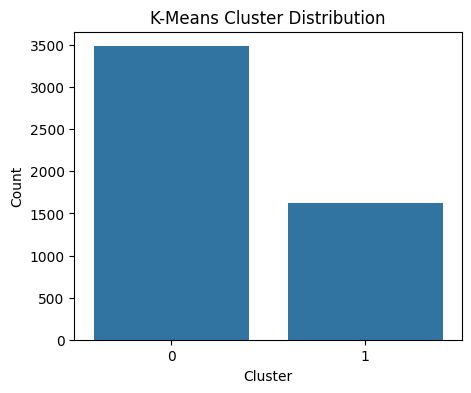

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(data=cluster_df, x="cluster")
plt.title("K-Means Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

In [ ]:
pd.crosstab(
    cluster_df["cluster"],
    cluster_df["stroke"],
    normalize="index"
).round(3)

stroke,0,1
cluster,,
0,0.929,0.071
1,0.998,0.002


## 12. Conclusion

In this project, I built and compared several machine learning models for stroke prediction.

Some important things I learned from the project were:

- healthcare datasets can have missing values and strong class imbalance
- accuracy alone is not enough for an imbalanced classification problem
- recall and F1-score are useful when the positive class is important
- SMOTE should be applied only to training data
- preprocessing should be included inside the machine learning pipeline
- cross-validation gives a better idea of how consistently a model performs

The model with the best performance can vary depending on the train/test split and model settings, so the results should be interpreted as a machine learning experiment rather than a medical prediction system.